# sentence confidence - clean

In [1]:
import os
from chat_gpt_asr.utils import remove_punctuations, ser
import json
import jiwer 
from tqdm import tqdm
import argparse
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import numpy as np
from dotenv import load_dotenv


root = "/home/mnaderi/Documents/thesis/chat-gpt-asr"

In [2]:
load_dotenv()
Root = os.getenv("ROOT_PATH")


In [3]:
def read_data(path):
  with open(path , "r") as f:
    return json.load(f)
        
def evaluate(items, thresh=1.0):
    hyp_l, ref_l = [], []   
    for item in items:
        if item["corrected_asr_transcription"] is None:
            continue 
        if "confidence_score" not in item["asr_transcription"]:
            continue 
           
        asr_transcription = item["asr_transcription"]["text"]
        confidence = item["asr_transcription"]["confidence_score"] 
        ref_transcription = item["reference_transcription"]  
        cor_transcription = item ["corrected_asr_transcription"]
        
        # remove trailing spaces, punctuations, and lower the case
        asr_transcription = jiwer.RemovePunctuation()(asr_transcription.strip().lower())
        ref_transcription = jiwer.RemovePunctuation()(ref_transcription.strip().lower())
        cor_transcription = jiwer.RemovePunctuation()(cor_transcription.strip().lower())
        
        ref_l.append(ref_transcription)
        
        # check confidence and append the suitable value to hyp_l       
        if confidence <= thresh:
            hyp_l.append(cor_transcription)
        else:
            hyp_l.append(asr_transcription)
            
    wer = jiwer.wer(ref_l, hyp_l) * 100
    
    
    return wer

In [4]:
t_tiny = os.path.join(Root, "results/results-dev-set/results_clean/results_tiny/results_best_prompt_tiny/results_GPT-3.5-Turbo_tiny/gpt-3.5-turbo-1106/results_sentence_confidence_new_prompts_tiny/results_find_best_prompt_tiny", "corrected_transcriptions_sentence_confidence_prompt_2.json")
t_medium = os.path.join(Root, "results/results-dev-set/results_clean/results_medium/results_sentence_confidence_medium/results_GPT-3.5-Turbo_medium/gpt-3.5-turbo-1106/results_without_sentence_confidence_medium","corrected_transcriptions_sentence_confidence_medium.json")
t_large = os.path.join(Root, "results/results-dev-set/results_clean/results_large-v3/results_sentence_confidence_large-v3/results_GPT-3.5-Turbo_large-v3/gpt-3.5-turbo-1106/results_without_sentence_confidence_large-v3","corrected_transcriptions_sentence_confidence_large-v3.json")


data_tiny = read_data(t_tiny)
data_medium = read_data(t_medium)
data_large = read_data(t_large)


In [5]:
# thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.50, 0.6, 0.7, 0.8, 0.9, 1]
thresholds = np.linspace(0, 1, 10)

res_sent = []
for thresh in thresholds:
    wer_tiny = evaluate(data_tiny, thresh)
    wer_medium = evaluate(data_medium, thresh)
    wer_large = evaluate(data_large, thresh)
    res_sent.append([wer_tiny, wer_medium, wer_large])

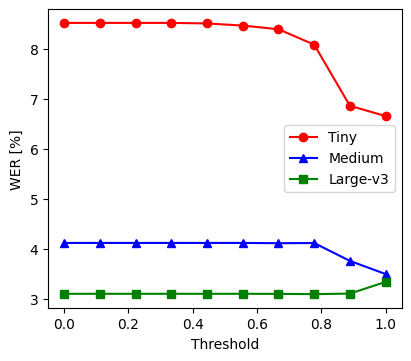

In [6]:
plt.figure(figsize=(4,3.5), constrained_layout=True)
y1 = np.array([r[0] for r in res_sent])
y2 = np.array([r[1] for r in res_sent])
y3 = np.array([r[2] for r in res_sent])
# y1 = y1 - y1.mean()
# y2 = y2 - y2.mean()
# y3 = y3 - y3.mean()
plt.plot(thresholds, y1, 'ro-', label='Tiny', )
plt.plot(thresholds, y2, 'b^-', label='Medium')
plt.plot(thresholds, y3, 'gs-', label='Large-v3')
plt.xlabel('Threshold')
plt.ylabel('WER [%]')
plt.legend()
plt.savefig('wer_vs_thresh_22.png', bbox_inches='tight')

# lowest word confidence - clean

In [7]:
t_tiny_lowest = os.path.join(root, "results/results-dev-set/results_clean/results_tiny/results_best_prompt_tiny/results_GPT-3.5-Turbo_tiny/gpt-3.5-turbo-1106/results_lowest_word_confidence_new_prompts_tiny/results_find_best_prompt_tiny","corrected_transcriptions_lowest_word_confidence_prompt_2.json")
t_medium_lowest = os.path.join(root, "results/results-dev-set/results_clean/results_medium/results_lowest_word_confidence_medium/results_GPT-3.5-Turbo_medium/gpt-3.5-turbo-1106/results_without_lowest_word_confidence_medium", "corrected_transcriptions_lowest_word_confidence_medium.json")
t_large_lowest = os.path.join(root, "results/results-dev-set/results_clean/results_large-v3/results_lowest_word_confidence_large-v3/results_GPT-3.5-Turbo_large-v3/gpt-3.5-turbo-1106/results_without_lowest_word_confidence_large-v3", "corrected_transcriptions_lowest_word_confidence_large-v3.json")
data_tiny_lowest = read_data(t_tiny_lowest)
data_medium_lowest = read_data(t_medium_lowest)
data_large_lowest = read_data(t_large_lowest)

In [8]:
# thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.50, 0.6, 0.7, 0.8, 0.9, 1]
thresholds = np.linspace(0, 1, 10)

res_lowest_word = []
for thresh in thresholds:
    wer_tiny_lowest = evaluate(data_tiny_lowest, thresh)
    wer_medium_lowest = evaluate(data_medium_lowest, thresh)
    wer_large_lowest = evaluate(data_large_lowest, thresh)
    res_lowest_word.append([wer_tiny_lowest, wer_medium_lowest, wer_large_lowest])

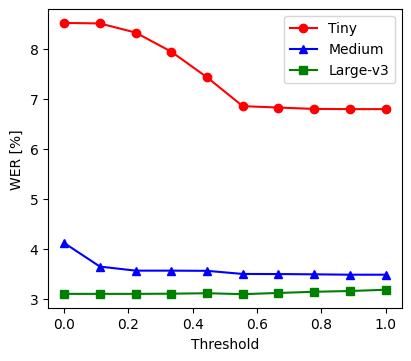

In [9]:
plt.figure(figsize=(4,3.5), constrained_layout=True)
y1 = np.array([r[0] for r in res_lowest_word])
y2 = np.array([r[1] for r in res_lowest_word])
y3 = np.array([r[2] for r in res_lowest_word])
# y1 = y1 - y1.mean()
# y2 = y2 - y2.mean()
# y3 = y3 - y3.mean()

plt.plot(thresholds, y1, 'ro-', label='Tiny', )
plt.plot(thresholds, y2, 'b^-', label='Medium')
plt.plot(thresholds, y3, 'gs-', label='Large-v3')
plt.xlabel('Threshold')
plt.ylabel('WER [%]')
plt.legend()
plt.savefig('wer_vs_thresh_33.png', bbox_inches='tight')

# Certain low confidence word experiment - clean

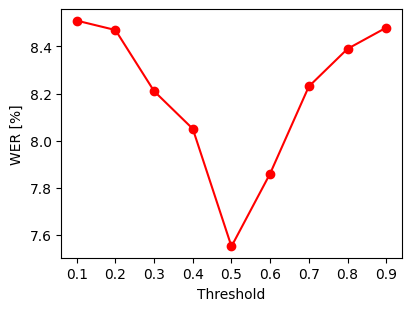

In [10]:
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9 ]
y = [8.51, 8.47, 8.21, 8.05, 7.55, 7.86, 8.23, 8.39, 8.48]

plt.figure(figsize=(4,3), constrained_layout=True)
plt.plot(x, y, 'o-r')
plt.xlabel("Threshold")
plt.ylabel("WER [%]")
plt.xticks(x)
plt.savefig("wer_vs_thresh_44.png", bbox_inches='tight')

# sentence confidence - noisy

In [10]:
# Increase font size for all elements
plt.rcParams.update({'font.size': 18})

In [11]:
t_tiny = os.path.join(root, "results/results-dev-set/results_noisy/results_tiny/results_sentence_confidence_tiny/results_GPT-3.5-Turbo_tiny/gpt-3.5-turbo-0125/results_without_sentence_confidence_tiny", "corrected_transcriptions_sentence_confidence_tiny.json")
t_medium = os.path.join(root, "results/results-dev-set/results_noisy/results_medium/results_sentence_confidence_medium/results_GPT-3.5-Turbo_medium/gpt-3.5-turbo-0125/results_without_sentence_confidence_medium","corrected_transcriptions_sentence_confidence_medium.json")
t_large = os.path.join(root, "results/results-dev-set/results_noisy/results_noisy_large-v3/results_sentence_confidence_noisy_large-v3/results_GPT-3.5-Turbo_noisy_large-v3/gpt-3.5-turbo-0125/results_without_sentence_confidence_noisy_large-v3","corrected_transcriptions_sentence_confidence_noisy_large-v3.json")


data_tiny = read_data(t_tiny)
data_medium = read_data(t_medium)
data_large = read_data(t_large)


In [12]:
# thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.50, 0.6, 0.7, 0.8, 0.9, 1]
thresholds = np.linspace(0, 1, 10)

res_sent = []
for thresh in thresholds:
    wer_tiny = evaluate(data_tiny, thresh)
    wer_medium = evaluate(data_medium, thresh)
    wer_large = evaluate(data_large, thresh)
    res_sent.append([wer_tiny, wer_medium, wer_large])

In [13]:
# debug
for n in data_medium:
    if not ("confidence_score" in n['asr_transcription']):
        print(n)

{'asr_transcription': {'text': '', 'segments': [], 'language': 'en'}, 'reference_transcription': 'MARGARET', 'corrected_asr_transcription': "I'm sorry, but the provided transcription is empty."}


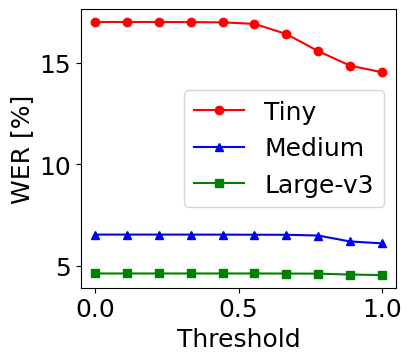

In [14]:
plt.figure(figsize=(4,3.5), constrained_layout=True)
y1 = np.array([r[0] for r in res_sent])
y2 = np.array([r[1] for r in res_sent])
y3 = np.array([r[2] for r in res_sent])
# y1 = y1 - y1.mean()
# y2 = y2 - y2.mean()
# y3 = y3 - y3.mean()
plt.plot(thresholds, y1, 'ro-', label='Tiny', )
plt.plot(thresholds, y2, 'b^-', label='Medium')
plt.plot(thresholds, y3, 'gs-', label='Large-v3')
plt.xlabel('Threshold')
# plt.yticks([])
plt.ylabel('WER [%]')
plt.legend()
plt.savefig('wer_vs_thresh_55.png', bbox_inches='tight')

# lowest word confidence - noisy

In [15]:
t_tiny_lowest = os.path.join(root, "results/results-dev-set/results_noisy/results_tiny/results_lowest_word_confidence_tiny/results_GPT-3.5-Turbo_tiny/gpt-3.5-turbo-0125/present_confidence_chatgpt/results_without_lowest_word_confidence_tiny","corrected_transcriptions_lowest_word_confidence_tiny.json")
t_medium_lowest = os.path.join(root, "results/results-dev-set/results_noisy/results_medium/results_lowest_word_confidence_medium/results_GPT-3.5-Turbo_medium/gpt-3.5-turbo-0125/results_without_lowest_word_confidence_medium", "corrected_transcriptions_lowest_word_confidence_medium.json")
t_large_lowest = os.path.join(root, "results/results-dev-set/results_noisy/results_noisy_large-v3/results_lowest_word_confidence_noisy_large-v3/results_GPT-3.5-Turbo_noisy_large-v3/gpt-3.5-turbo-0125/results_without_lowest_word_confidence_noisy_large-v3", "corrected_transcriptions_lowest_word_confidence_noisy_large-v3.json")
data_tiny_lowest = read_data(t_tiny_lowest)
data_medium_lowest = read_data(t_medium_lowest)
data_large_lowest = read_data(t_large_lowest)

In [16]:
# thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.50, 0.6, 0.7, 0.8, 0.9, 1]
thresholds = np.linspace(0, 1, 10)

res_lowest_word = []
for thresh in thresholds:
    wer_tiny_lowest = evaluate(data_tiny_lowest, thresh)
    wer_medium_lowest = evaluate(data_medium_lowest, thresh)
    wer_large_lowest = evaluate(data_large_lowest, thresh)
    res_lowest_word.append([wer_tiny_lowest, wer_medium_lowest, wer_large_lowest])

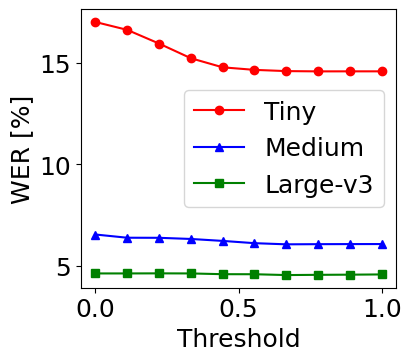

In [17]:
plt.figure(figsize=(4,3.5), constrained_layout=True)
y1 = np.array([r[0] for r in res_lowest_word])
y2 = np.array([r[1] for r in res_lowest_word])
y3 = np.array([r[2] for r in res_lowest_word])
# y1 = y1 - y1.mean()
# y2 = y2 - y2.mean()
# y3 = y3 - y3.mean()

plt.plot(thresholds, y1, 'ro-', label='Tiny', )
plt.plot(thresholds, y2, 'b^-', label='Medium')
plt.plot(thresholds, y3, 'gs-', label='Large-v3')
plt.xlabel('Threshold')
plt.ylabel('WER [%]')
plt.legend()
plt.savefig('wer_vs_thresh_66.png', bbox_inches='tight')

In [19]:
import os
os.getcwd()

'/home/mnaderi/Documents/thesis/chat-gpt-asr/notebooks'

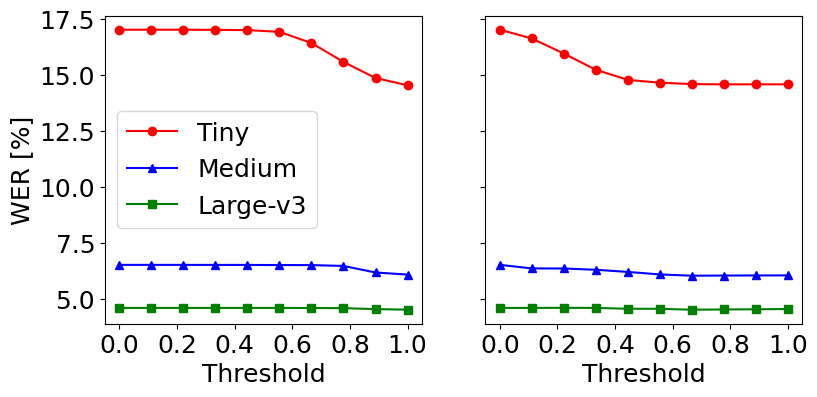

In [39]:
fig,(ax1,ax2) = plt.subplots(1,2, figsize=(9,4.), sharey=True, )
plt.subplots_adjust(hspace=0.2) 

y1 = np.array([r[0] for r in res_sent])
y2 = np.array([r[1] for r in res_sent])
y3 = np.array([r[2] for r in res_sent])
# y1 = y1 - y1.mean()
# y2 = y2 - y2.mean()
# y3 = y3 - y3.mean()
ax1.plot(thresholds, y1, 'ro-', label='Tiny', )
ax1.plot(thresholds, y2, 'b^-', label='Medium')
ax1.plot(thresholds, y3, 'gs-', label='Large-v3')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('WER [%]')
ax1.legend(loc=6)




y1 = np.array([r[0] for r in res_lowest_word])
y2 = np.array([r[1] for r in res_lowest_word])
y3 = np.array([r[2] for r in res_lowest_word])
# y1 = y1 - y1.mean()
# y2 = y2 - y2.mean()
# y3 = y3 - y3.mean()

ax2.plot(thresholds, y1, 'ro-', label='Tiny', )
ax2.plot(thresholds, y2, 'b^-', label='Medium')
ax2.plot(thresholds, y3, 'gs-', label='Large-v3')
ax2.set_xlabel('Threshold')


ax1.set_xticks(ticks=[0,0.2,0.4,0.6,0.8,1.])
ax2.set_xticks(ticks=[0,0.2,0.4,0.6,0.8,1.])

# ax2.set_ylabel('WER [%]')
# ax2.legend()
# ax2.set_xlabel()

fig.savefig('wer-vs-threshold-dev-other-together-1.pdf',bbox_inches="tight")